In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import scipy.stats as stats
from scipy.stats import anderson, mannwhitneyu, kruskal
from scipy.signal import find_peaks

In [3]:
df = pd.read_csv('mercedes_benz_sales_2020_2025.csv')
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,1,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,1,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,1,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,1,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,1,Yes


In [4]:
df.shape

(12132666, 9)

In [5]:
df.isnull().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(3153)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12132666 entries, 0 to 12132665
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Sales Volume      int64 
 8   Turbo             object
dtypes: int64(4), object(5)
memory usage: 833.1+ MB


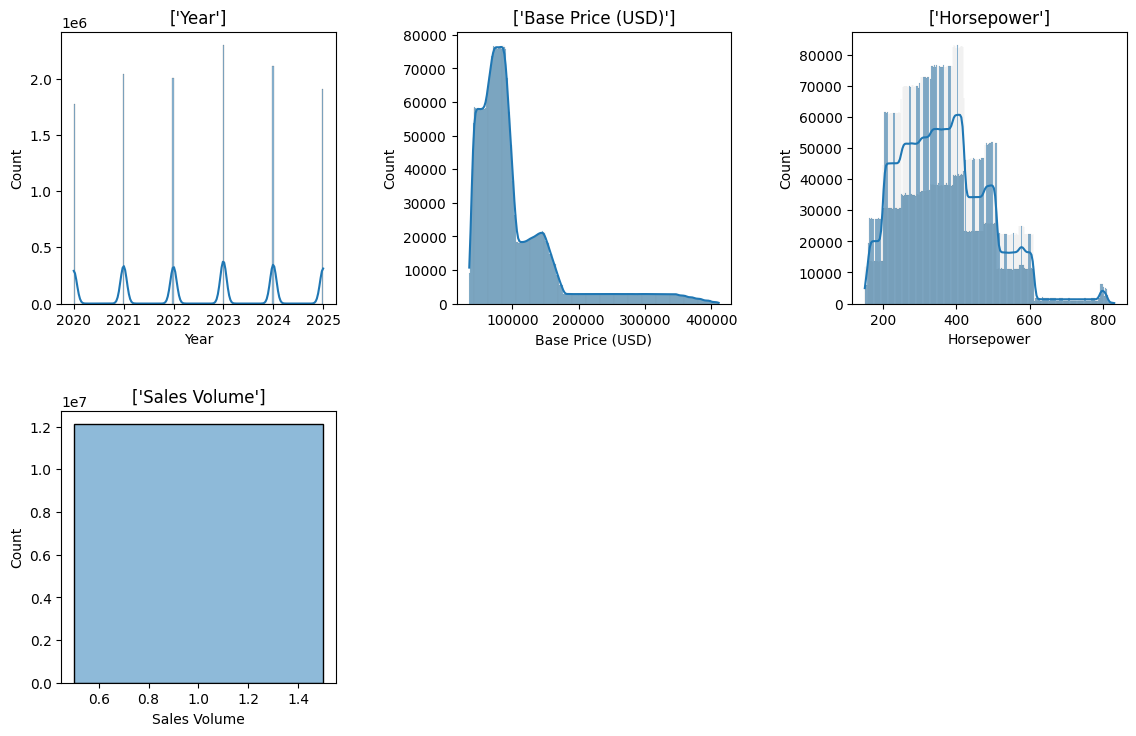

In [8]:
num_col = df.select_dtypes(exclude='object').columns

plt.figure(figsize=(12,8))

for i, col in enumerate(num_col,1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title([col])

plt.tight_layout(pad=3)
plt.show()

In [9]:
df[num_col].skew()

Year               -0.044999
Base Price (USD)    2.156508
Horsepower          0.620531
Sales Volume        0.000000
dtype: float64

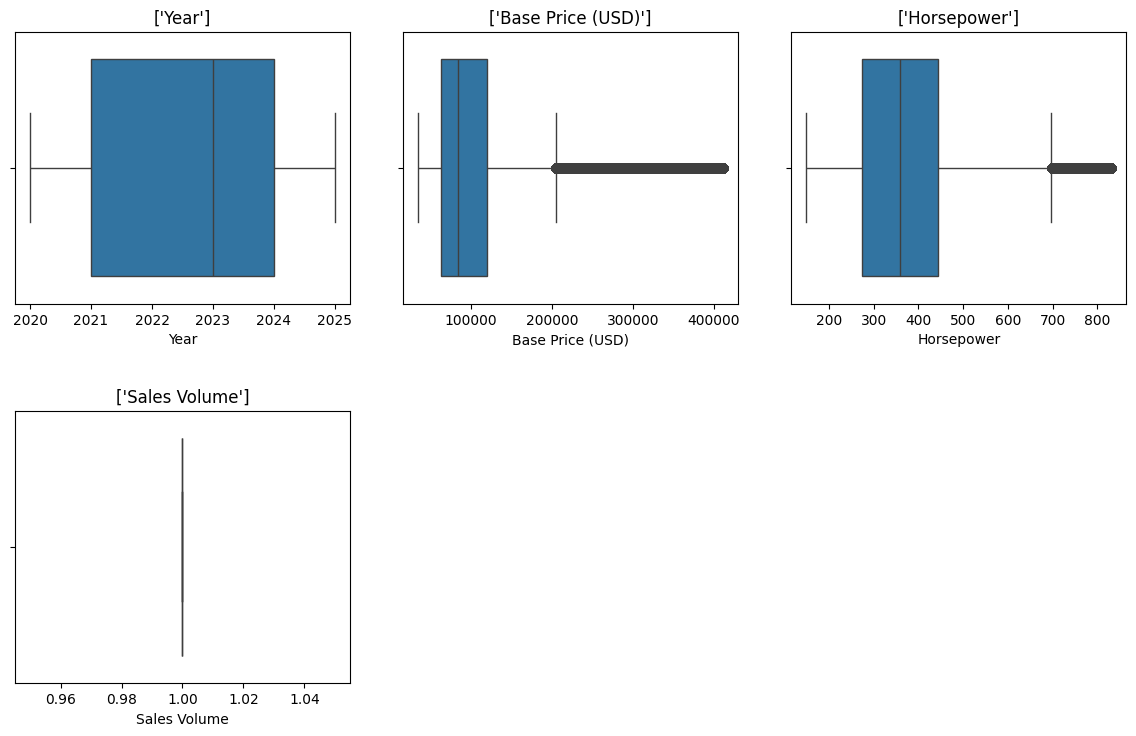

In [10]:
num_col = df.select_dtypes(exclude='object').columns

plt.figure(figsize=(12,8))

for i, col in enumerate(num_col,1):
    plt.subplot(2,3,i)
    sns.boxplot(x = df[col])
    plt.title([col])

plt.tight_layout(pad=3)
plt.show()

<Axes: xlabel='Horsepower', ylabel='Base Price (USD)'>

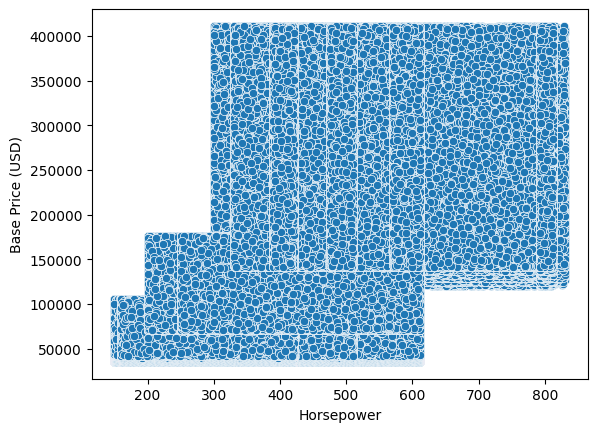

In [11]:
sns.scatterplot(x = df['Horsepower'], y=df['Base Price (USD)'])

In [12]:
corr = df[num_col].corr(method='spearman')['Base Price (USD)'].sort_values(ascending=False)
corr

Base Price (USD)    1.000000
Horsepower          0.353507
Year                0.118015
Sales Volume             NaN
Name: Base Price (USD), dtype: float64

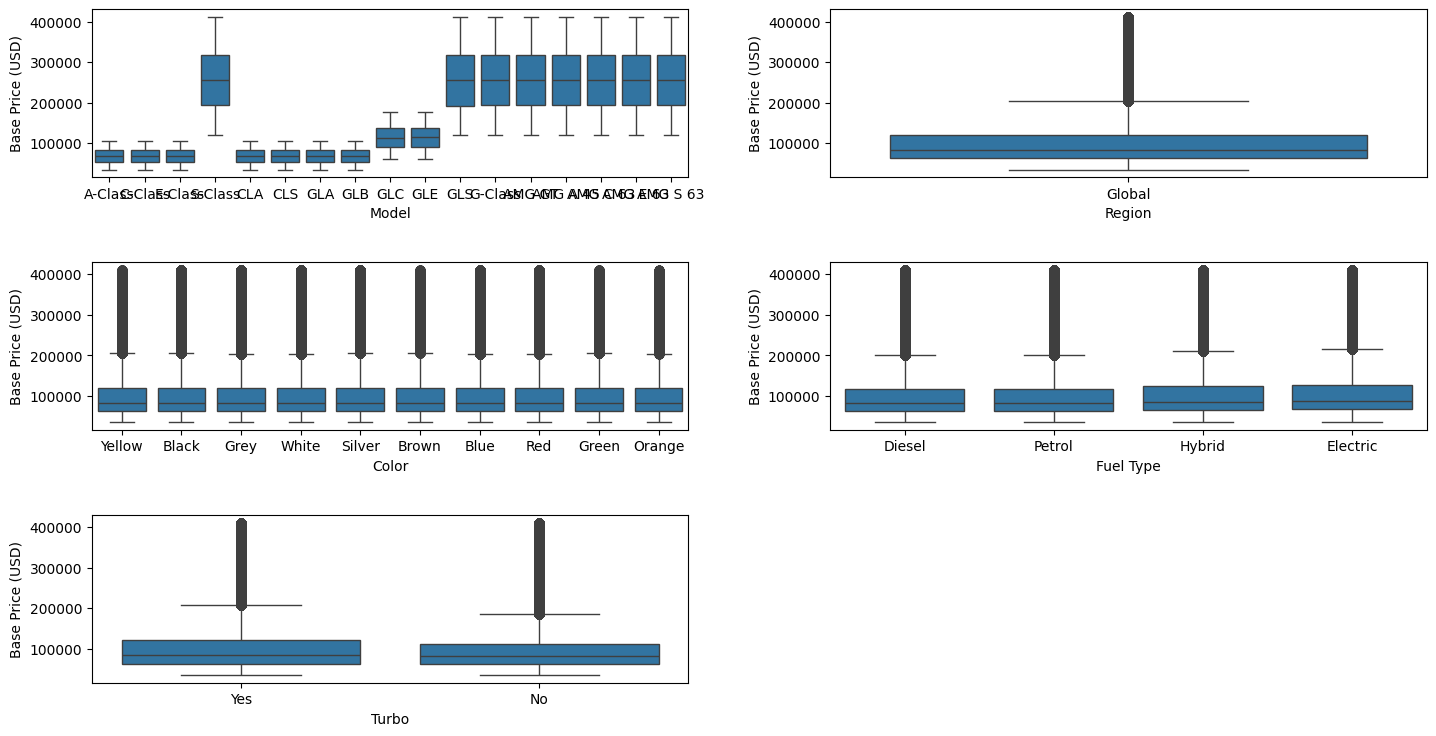

In [13]:
cat_col = df.select_dtypes(exclude=['int64','float64']).columns

target = df['Base Price (USD)']

plt.figure(figsize=(15,8))

for i, col in enumerate(cat_col,1):
    plt.subplot(3,2,i)
    sns.boxplot(x=df[col], y= target)

plt.tight_layout(pad=3)
plt.show()

In [14]:
# ambil sample (boleh adjust size)
df_sample = df.sample(n=20000, random_state=42)

print("Original size:", df.shape)
print("Sample size:", df_sample.shape)

Original size: (12132666, 9)
Sample size: (20000, 9)


In [15]:
target = 'Base Price (USD)'

# auto detect categorical columns
cat_cols = df_sample.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", cat_cols)

Categorical columns: ['Model', 'Region', 'Color', 'Fuel Type', 'Turbo']


In [16]:
def run_nonparametric_tests(df, cat_cols, target):
    results = []

    for col in cat_cols:
        groups = df.groupby(col)[target]

        n_groups = df[col].nunique()

        try:
            if n_groups == 2:
                # Mann-Whitney
                group_names = list(groups.groups.keys())
                g1 = groups.get_group(group_names[0])
                g2 = groups.get_group(group_names[1])

                stat, p = mannwhitneyu(g1, g2, alternative='two-sided')

                test_type = 'Mann-Whitney'

            elif n_groups > 2:
                # Kruskal-Wallis
                group_list = [group for name, group in groups]

                stat, p = kruskal(*group_list)

                test_type = 'Kruskal-Wallis'

            else:
                continue

            results.append({
                'feature': col,
                'test': test_type,
                'n_groups': n_groups,
                'statistic': stat,
                'p_value': p,
                'significant': p < 0.05
            })

        except Exception as e:
            print(f"Error with column {col}: {e}")

    return pd.DataFrame(results)

In [17]:
results_df = run_nonparametric_tests(df_sample, cat_cols, target)

# sort by p-value
results_df = results_df.sort_values(by='p_value')

results_df

,feature,test,n_groups,statistic,p_value,significant
0,Model,Kruskal-Wallis,17,1.201067e+04,0.000000e+00,True
2,Fuel Type,Kruskal-Wallis,4,9.516553e+01,1.701144e-20,True
3,Turbo,Mann-Whitney,2,2.386487e+07,3.521889e-04,True
1,Color,Kruskal-Wallis,10,4.758716e+00,8.548140e-01,False


In [18]:
# features yang significant
significant_features = results_df[results_df['significant'] == True]

print("Significant features:")
print(significant_features[['feature', 'test', 'p_value']])

Significant features:
     feature            test       p_value
0      Model  Kruskal-Wallis  0.000000e+00
2  Fuel Type  Kruskal-Wallis  1.701144e-20
3      Turbo    Mann-Whitney  3.521889e-04


In [19]:
# =========================
# 1. Cliff's Delta (FAST)
# =========================
def cliffs_delta_fast(x, y):
    x = np.sort(np.array(x))
    y = np.sort(np.array(y))

    nx = len(x)
    ny = len(y)

    i = j = more = less = 0

    while i < nx and j < ny:
        if x[i] > y[j]:
            more += nx - i
            j += 1
        elif x[i] < y[j]:
            less += ny - j
            i += 1
        else:
            i += 1
            j += 1

    return (more - less) / (nx * ny)


# =========================
# 2. Eta Squared
# =========================
def kruskal_eta_squared(H, k, n):
    return (H - k + 1) / (n - k)


# =========================
# 3. Interpretation function
# =========================
def interpret_effect_size(effect, test_type):
    effect_abs = abs(effect)

    if test_type == 'Cliff':
        if effect_abs < 0.1:
            return 'Negligible'
        elif effect_abs < 0.3:
            return 'Small'
        elif effect_abs < 0.5:
            return 'Medium'
        else:
            return 'Large'

    elif test_type == 'Eta':
        if effect_abs < 0.01:
            return 'Negligible'
        elif effect_abs < 0.06:
            return 'Small'
        elif effect_abs < 0.14:
            return 'Medium'
        else:
            return 'Large'


# =========================
# 4. MAIN FUNCTION
# =========================
def analyze_categorical_features(df, target):

    # detect categorical (low cardinality sahaja)
    cat_cols = [
        col for col in df.select_dtypes(include=['object', 'category']).columns
        if df[col].nunique() <= 50
    ]

    results = []

    for col in cat_cols:
        n_groups = df[col].nunique()
        groups = df.groupby(col)[target]

        try:
            # =====================
            # CASE 1: 2 kategori
            # =====================
            if n_groups == 2:
                g_names = list(groups.groups.keys())
                g1 = groups.get_group(g_names[0])
                g2 = groups.get_group(g_names[1])

                # Mann-Whitney (optional, for p-value)
                stat, p = mannwhitneyu(g1, g2)

                # Effect size
                effect = cliffs_delta_fast(g1, g2)
                effect_type = "Cliff's Delta"
                interpretation = interpret_effect_size(effect, 'Cliff')

            # =====================
            # CASE 2: >2 kategori
            # =====================
            elif n_groups > 2:
                group_list = [g for _, g in groups]

                stat, p = kruskal(*group_list)

                k = len(group_list)
                n = len(df)

                effect = kruskal_eta_squared(stat, k, n)
                effect_type = "Eta Squared"
                interpretation = interpret_effect_size(effect, 'Eta')

            else:
                continue

            results.append({
                'feature': col,
                'n_groups': n_groups,
                'test': 'MW' if n_groups == 2 else 'KW',
                'p_value': p,
                'effect_size': effect,
                'effect_type': effect_type,
                'effect_strength': interpretation
            })

        except Exception as e:
            print(f"Error on {col}: {e}")

    return pd.DataFrame(results).sort_values(
        by='effect_size', key=abs, ascending=False
    )

In [20]:
df_sample = df.sample(n=20000, random_state=42)

result = analyze_categorical_features(df_sample, 'Base Price (USD)')

result

,feature,n_groups,test,p_value,effect_size,effect_type,effect_strength
0,Model,17,KW,0.000000e+00,0.600244,Eta Squared,Large
3,Turbo,2,MW,3.521889e-04,0.026920,Cliff's Delta,Negligible
2,Fuel Type,4,KW,1.701144e-20,0.004609,Eta Squared,Negligible
1,Color,10,KW,8.548140e-01,-0.000212,Eta Squared,Negligible


In [21]:
df[cat_cols].columns

Index(['Model', 'Region', 'Color', 'Fuel Type', 'Turbo'], dtype='object')

In [22]:
df.Region.value_counts()

Region
Global    12132666
Name: count, dtype: int64

In [23]:
x = df[['Model', 'Fuel Type', 'Turbo', 'Horsepower']]
y = df['Base Price (USD)']

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_squared_error
import optuna

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [26]:
cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers= [
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [27]:
pipeline = Pipeline(
    steps= [ 
        ('preprocessor', preprocessor),
        ('modelrf', XGBRegressor())
    ]
)

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('modelrf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [28]:
y_pred = pipeline.predict(x_test)
y_pred

array([269571.97 ,  67088.18 ,  66865.   , ..., 252505.8  ,  70164.22 ,
       117924.055], shape=(2426534,), dtype=float32)

In [29]:
print('RMSE:', root_mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

RMSE: 32671.677734375
MAE: 23723.423828125
R2: 0.7676804661750793


In [30]:
from sklearn.model_selection import cross_val_score

# TRAIN prediction
y_train_pred = pipeline.predict(x_train)

# TRAIN metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# TEST metrics (kamu dah ada, ulang untuk consistency)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# CV (guna RMSE)
cv_scores = cross_val_score(
    pipeline, x_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores

print("=== TRAIN ===")
print("RMSE:", train_rmse)
print("MAE:", train_mae)
print("R2:", train_r2)

print("\n=== TEST ===")
print("RMSE:", test_rmse)
print("MAE:", test_mae)
print("R2:", test_r2)

print("\n=== CV ===")
print("RMSE mean:", cv_rmse.mean())
print("RMSE std:", cv_rmse.std())

=== TRAIN ===
RMSE: 32672.951993965897
MAE: 23725.732421875
R2: 0.7680872678756714

=== TEST ===
RMSE: 32671.677765306147
MAE: 23723.423828125
R2: 0.7676804661750793

=== CV ===
RMSE mean: 32694.975
RMSE std: 24.739425107772533


In [31]:
from lightgbm import LGBMRegressor

pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor())
])

pipeline_lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.714861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 9706132, number of used features: 4
[LightGBM] [Info] Start training from score 104226.708017


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [32]:
y_predlgbm = pipeline_lgbm.predict(x_test)

c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [33]:
print('RMSE:', root_mean_squared_error(y_test, y_predlgbm))
print('MAE:', mean_absolute_error(y_test, y_predlgbm))
print('R2:', r2_score(y_test, y_predlgbm))

RMSE: 32665.792842292103
MAE: 23721.16571964482
R2: 0.7677642033677649


In [34]:
# TRAIN prediction
y_train_predlgbm = pipeline_lgbm.predict(x_train)

# TRAIN metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_predlgbm))
train_mae = mean_absolute_error(y_train, y_train_predlgbm)
train_r2 = r2_score(y_train, y_train_predlgbm)

# TEST metrics (kamu dah ada, ulang untuk consistency)
test_rmse = np.sqrt(mean_squared_error(y_test, y_predlgbm))
test_mae = mean_absolute_error(y_test, y_predlgbm)
test_r2 = r2_score(y_test, y_predlgbm)

# CV (guna RMSE)
cv_scores = cross_val_score(
    pipeline_lgbm, x_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores

print("=== TRAIN ===")
print("RMSE:", train_rmse)
print("MAE:", train_mae)
print("R2:", train_r2)

print("\n=== TEST ===")
print("RMSE:", test_rmse)
print("MAE:", test_mae)
print("R2:", test_r2)

print("\n=== CV ===")
print("RMSE mean:", cv_rmse.mean())
print("RMSE std:", cv_rmse.std())
print('var', cv_rmse.std()/cv_rmse.mean())

c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 7764905, number of used features: 4
[LightGBM] [Info] Start training from score 104224.319336


c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 7764905, number of used features: 4
[LightGBM] [Info] Start training from score 104220.373504


c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 7764906, number of used features: 4
[LightGBM] [Info] Start training from score 104214.318665


c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 7764906, number of used features: 4
[LightGBM] [Info] Start training from score 104222.108044


c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 7764906, number of used features: 4
[LightGBM] [Info] Start training from score 104252.420531


c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== TRAIN ===
RMSE: 32680.90588238538
MAE: 23730.842162380315
R2: 0.7679743289099729

=== TEST ===
RMSE: 32665.792842292103
MAE: 23721.16571964482
R2: 0.7677642033677649

=== CV ===
RMSE mean: 32688.517173741584
RMSE std: 24.44701837780615
var 0.0007478778632835704


In [35]:
model = pipeline_lgbm.named_steps['model']
feature_names = pipeline_lgbm.named_steps['preprocessor'].get_feature_names_out()
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feat_imp)

           feature  importance
3  num__Horsepower        1136
1   cat__Fuel Type         969
0       cat__Model         719
2       cat__Turbo         176


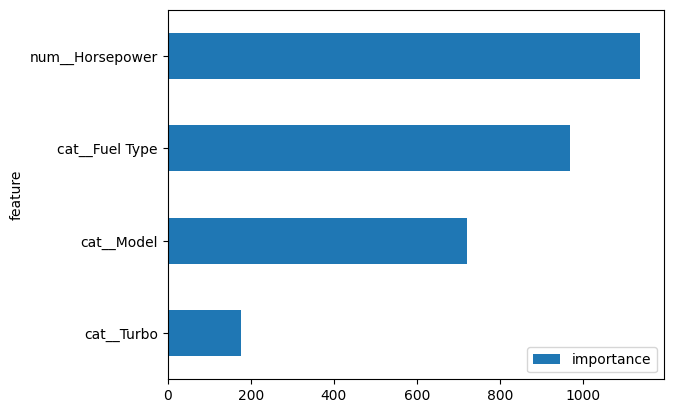

In [36]:
feat_imp.head(10).plot(
    x='feature',
    y='importance',
    kind='barh'
)
plt.gca().invert_yaxis()
plt.show()

In [ ]:
def objective(trial):
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = LGBMRegressor(**params)

    pipeline_lgbm = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # guna RMSE
    scores = cross_val_score(
        pipeline_lgbm,
        x_train,
        y_train,
        cv=3,  # guna 3 dulu sebab dataset besar
        scoring='neg_root_mean_squared_error'
    )

    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

In [38]:
test_data = pd.DataFrame({
    'Model': ['C-Class', 'A-Class'],
    'Fuel Type': ['Petrol', 'Diesel'],
    'Turbo': ['Yes', 'No'],
    'Horsepower': [200, 150]
})

preds = pipeline_lgbm.predict(test_data)
print(preds)

[67007.88513211 66922.14840179]


c:\Users\zuhairi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
